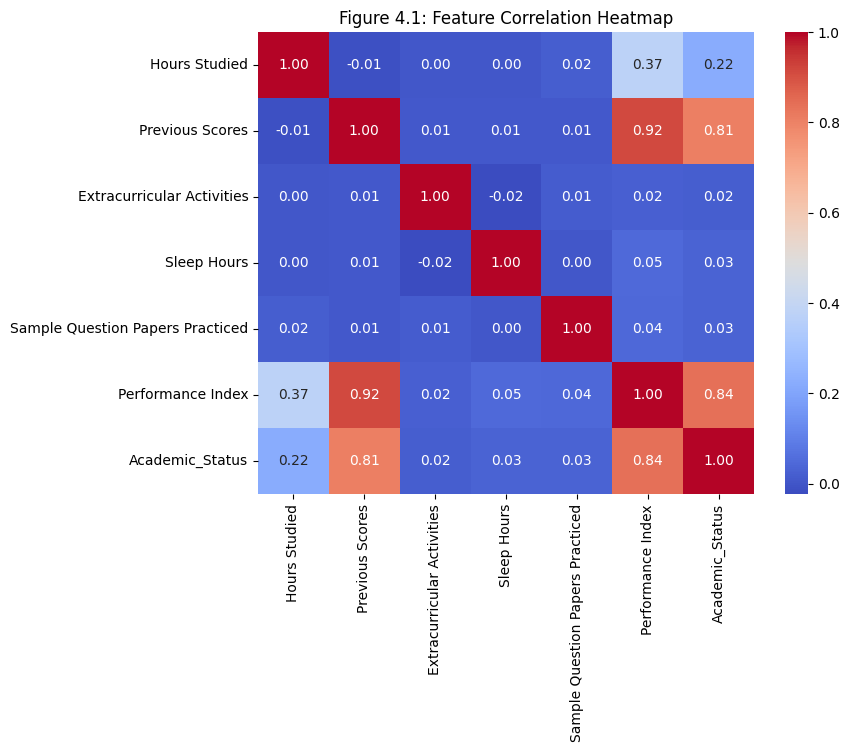

C:\Users\Felix Joseph Dinopol\AppData\Local\Temp\ipykernel_12164\2382992062.py:36: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([Y_cont_test.min(), Y_cont_test.max()], [Y_cont_test.min(), Y_cont_test.max()], 'k--', lw=2, color='red')


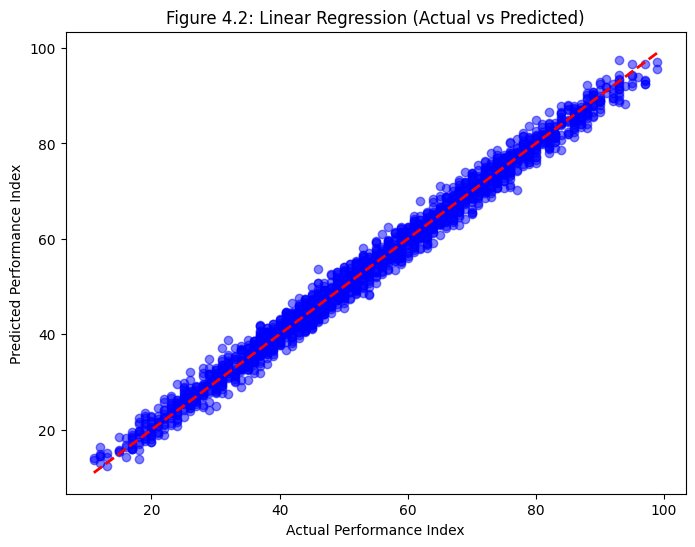

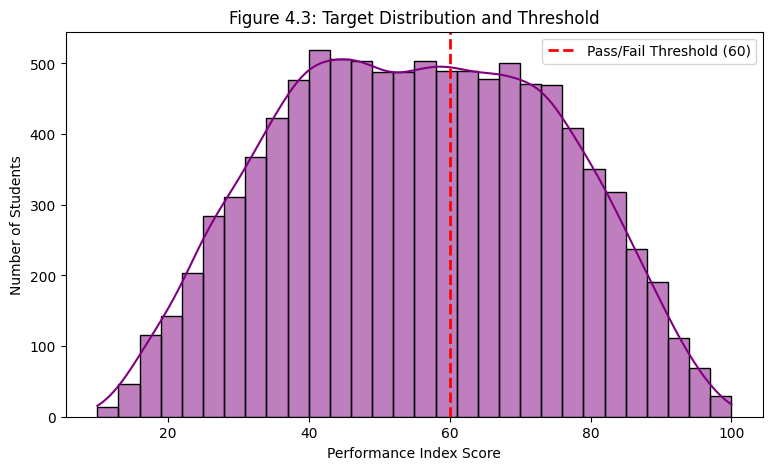

C:\Users\Felix Joseph Dinopol\AppData\Local\Temp\ipykernel_12164\2382992062.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['Extracurricular Activities'].map({1: 'Yes', 0: 'No'}), y=df['Performance Index'], palette='Set2')


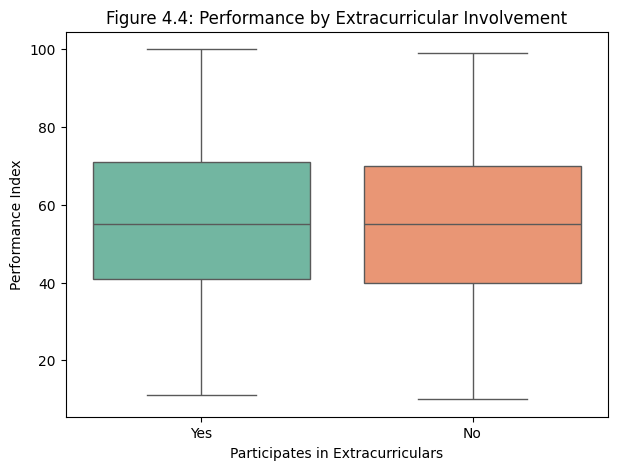

C:\Users\Felix Joseph Dinopol\AppData\Local\Temp\ipykernel_12164\2382992062.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dt_model.feature_importances_, y=X.columns, palette='viridis')


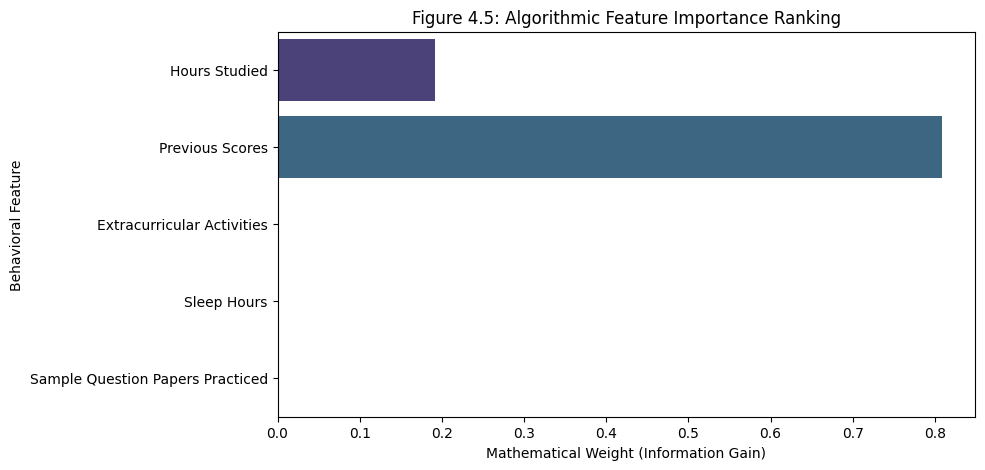

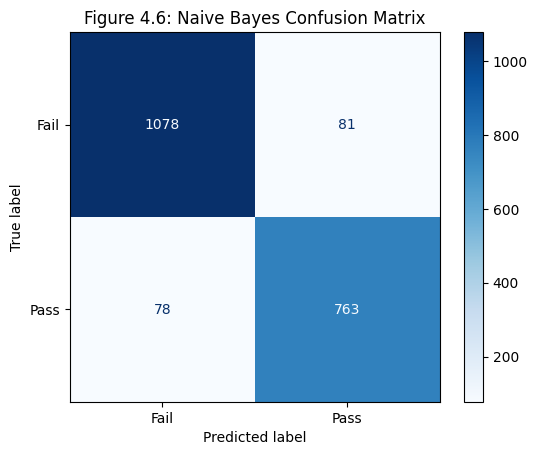

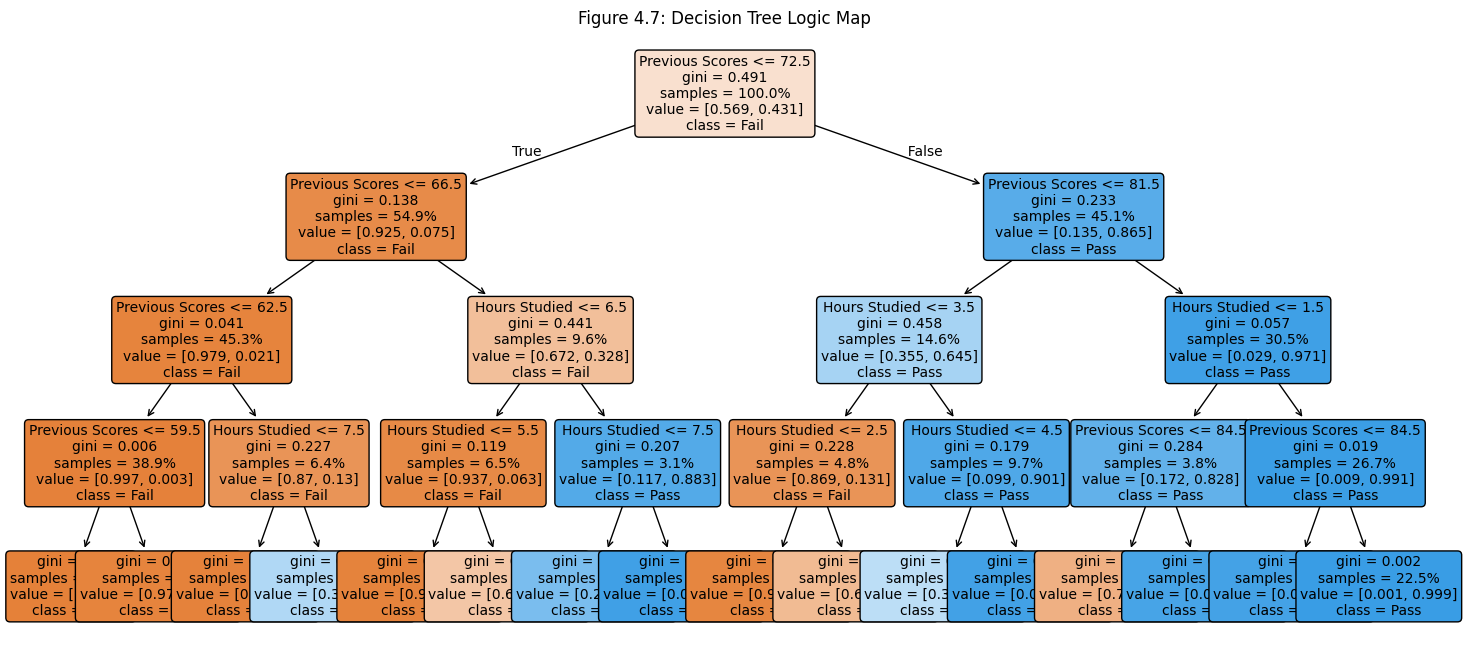

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# --- INITIAL SETUP & PREPROCESSING ---
df = pd.read_csv('Student_Performance.csv')
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'Yes': 1, 'No': 0})
df['Academic_Status'] = (df['Performance Index'] >= 60).astype(int)

X = df[['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced']]
Y_cont = df['Performance Index']
Y_bin = df['Academic_Status']

X_train, X_test, Y_cont_train, Y_cont_test = train_test_split(X, Y_cont, test_size=0.2, random_state=42)
_, _, Y_bin_train, Y_bin_test = train_test_split(X, Y_bin, test_size=0.2, random_state=42)

# --- FIGURE 4.1: HEATMAP ---
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Figure 4.1: Feature Correlation Heatmap")
plt.show()

# --- FIGURE 4.2: REGRESSION SCATTER PLOT ---
lr_model = LinearRegression()
lr_model.fit(X_train, Y_cont_train)
lr_predictions = lr_model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(Y_cont_test, lr_predictions, alpha=0.5, color='blue')
plt.plot([Y_cont_test.min(), Y_cont_test.max()], [Y_cont_test.min(), Y_cont_test.max()], 'k--', lw=2, color='red')
plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title("Figure 4.2: Linear Regression (Actual vs Predicted)")
plt.show()

# --- FIGURE 4.3: THRESHOLD HISTOGRAM ---
plt.figure(figsize=(9, 5))
sns.histplot(df['Performance Index'], bins=30, kde=True, color='purple')
plt.axvline(60, color='red', linestyle='dashed', linewidth=2, label='Pass/Fail Threshold (60)')
plt.title("Figure 4.3: Target Distribution and Threshold")
plt.xlabel("Performance Index Score")
plt.ylabel("Number of Students")
plt.legend()
plt.show()

# --- FIGURE 4.4: BOX PLOT ---
plt.figure(figsize=(7, 5))
sns.boxplot(x=df['Extracurricular Activities'].map({1: 'Yes', 0: 'No'}), y=df['Performance Index'], palette='Set2')
plt.title("Figure 4.4: Performance by Extracurricular Involvement")
plt.xlabel("Participates in Extracurriculars")
plt.ylabel("Performance Index")
plt.show()

# --- FIGURE 4.5: FEATURE IMPORTANCE ---
dt_model = DecisionTreeClassifier(random_state=42, max_depth=4)
dt_model.fit(X_train, Y_bin_train)

plt.figure(figsize=(9, 5))
sns.barplot(x=dt_model.feature_importances_, y=X.columns, palette='viridis')
plt.title("Figure 4.5: Algorithmic Feature Importance Ranking")
plt.xlabel("Mathematical Weight (Information Gain)")
plt.ylabel("Behavioral Feature")
plt.show()

# --- FIGURE 4.6: CONFUSION MATRIX ---
nb_model = GaussianNB()
nb_model.fit(X_train, Y_bin_train)
nb_predictions = nb_model.predict(X_test)

cm = confusion_matrix(Y_bin_test, nb_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fail', 'Pass'])
disp.plot(cmap='Blues')
plt.title("Figure 4.6: Naive Bayes Confusion Matrix")
plt.show()

# --- FIGURE 4.7: DECISION TREE LOGIC MAP ---
plt.figure(figsize=(18, 8))
plot_tree(dt_model, filled=True, feature_names=X.columns, class_names=['Fail', 'Pass'], rounded=True, proportion=True, fontsize=10)
plt.title("Figure 4.7: Decision Tree Logic Map")
plt.show()